In [ ]:
# ==========================================
# Helper Functions
# ==========================================

def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)
    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax=axes[0])
    axes[0].set_title("Raw Counts")
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax=axes[1])
    axes[1].set_title("Normalized Confusion Matrix")
    fig.tight_layout()
    plt.show()
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test="Reds", colorbar=False):
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(y_train, y_train_pred,
                                     output_dict=True, figsize=figsize,
                                     colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
    print()
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(y_test, y_test_pred,
                                  output_dict=True, figsize=figsize,
                                  colorbar=colorbar, cmap=cmap_test,
                                  label='Test Data')
    if output_dict==True:
        results_dict = {'train': results_train, 'test': results_test}
        return results_dict

print('✅ Helper Functions Ready!')

✅ Helper Functions Ready!


In [ ]:
import joblib


best_lr = joblib.load('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/best_lr_model.pkl')
best_knn = joblib.load('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/best_knn_model.pkl')
best_rf = joblib.load('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/best_rf_model.pkl')

print('✅ Models loaded!')

In [ ]:
evaluate_classification(best_lr, X_train, y_train, X_test, y_test)
evaluate_classification(best_rf, X_train, y_train, X_test, y_test)
evaluate_classification(best_knn, X_train, y_train, X_test, y_test)

#**Business Understanding**

# 🏦 Loan Default Prediction

## 1. Business Understanding

### Problem Statement
Banks and financial institutions face significant risk when customers
fail to repay their loans (Loan Default).
This leads to major financial losses and impacts the institution's stability.

### Goal
Build a machine learning model that predicts whether a customer
will default on their loan based on their personal and financial data.

### Why It Matters
- Reduce financial losses for the bank
- Make smarter loan approval decisions
- Identify high-risk customers before approving loans

### Most Important Metric
Recall — because missing a customer who will default
is far more costly than rejecting a reliable customer.

### Target Variable
- 0 = Customer repaid the loan ✅
- 1 = Customer defaulted on the loan ❌

#**Step 2 — Imports**

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn - Evaluation
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             RocCurveDisplay)

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')


#**Step 3 — Load Data**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Loan_default.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

df.head()

Dataset Shape: (255347, 18)
Rows: 255,347
Columns: 18


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


#**Data Understanding**

#**Step 4 — Initial Inspection**

In [ ]:
# Basic Info
print('='*50)
print('DATASET SHAPE')
print('='*50)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

print('\n' + '='*50)
print('COLUMN TYPES')
print('='*50)
print(df.dtypes)

print('\n' + '='*50)
print('BASIC STATISTICS')
print('='*50)
df.describe()

DATASET SHAPE
Rows: 255,347
Columns: 18

COLUMN TYPES
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

BASIC STATISTICS


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


#**Step 5 — Target Variable Distribution**

TARGET VARIABLE DISTRIBUTION
Default
0    225694
1     29653
Name: count, dtype: int64

Default Rate: 11.61%


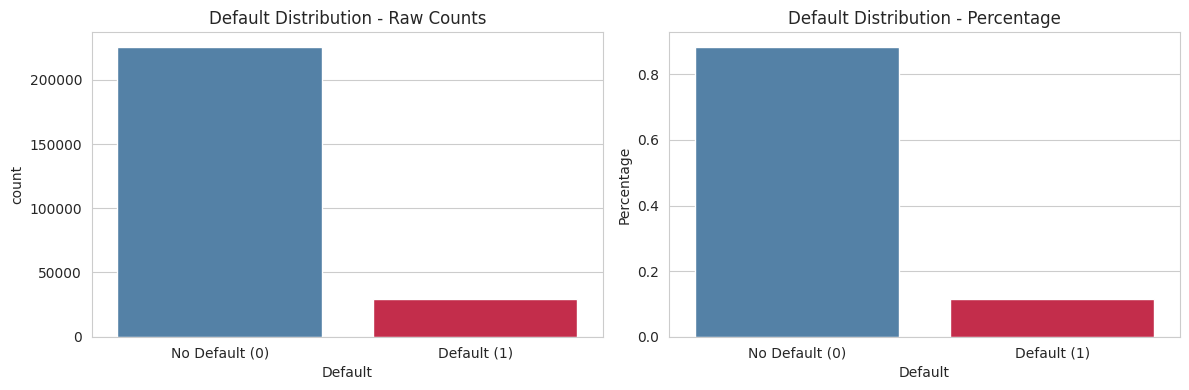

In [ ]:
print('='*50)
print('TARGET VARIABLE DISTRIBUTION')
print('='*50)
print(df['Default'].value_counts())
print(f'\nDefault Rate: {df["Default"].mean()*100:.2f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw Counts
sns.countplot(data=df, x='Default', palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('Default Distribution - Raw Counts')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'])

# Percentage
default_pct = df['Default'].value_counts(normalize=True).reset_index()
default_pct.columns = ['Default', 'Percentage']
sns.barplot(data=default_pct, x='Default', y='Percentage',
            palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('Default Distribution - Percentage')
axes[1].set_xticklabels(['No Default (0)', 'Default (1)'])

plt.tight_layout()
plt.show()



### Target Variable Analysis

**Key Findings:**

- The dataset is heavily imbalanced:
  - No Default (0): 225,694 customers → 88.39%
  - Default (1):  29,653 customers  → 11.61%

- Only 11.61% of customers defaulted on their loan.

- ⚠️ This imbalance means accuracy alone is misleading:
  A model predicting "No Default" for everyone would still
  achieve 88% accuracy without learning anything useful.

**How We Will Handle This:**
- Use class_weight='balanced' in our models
- Primary metric = Recall (not Accuracy)
- Because missing a real defaulter is far more costly
  than flagging a reliable customer for review.

#**Step 6 — Missing Values**

MISSING VALUES
Total Missing Values: 0
Series([], dtype: int64)


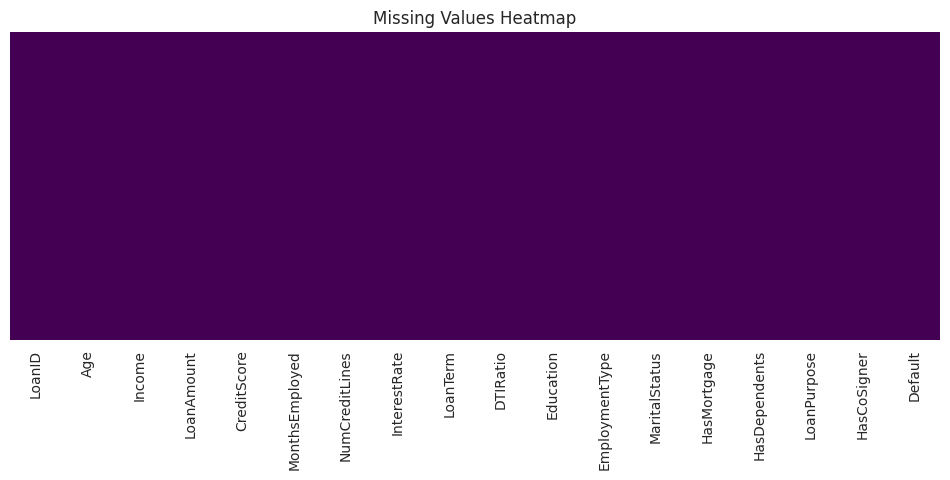

In [ ]:
print('='*50)
print('MISSING VALUES')
print('='*50)
# Missing Values Check
print(f'Total Missing Values: {df.isnull().sum().sum()}')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

#**Step 7 — Duplicates**

In [ ]:
print('='*50)
print('DUPLICATES')
print('='*50)
print(f'Total Duplicates: {df.duplicated().sum()}')

# Drop duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed! New shape: {df.shape}')
else:
    print('No duplicates found')

DUPLICATES
Total Duplicates: 0
No duplicates found


#**Data Understanding Summary**



| Check              | Result                        |
|--------------------|-------------------------------|
| Missing Values     | None ✅                       |
| Duplicates         | None ✅                       |
| Class Balance      | Imbalanced ⚠️                 |
| Default Rate       | 11.61%                        |
| No Default         | 225,694 (88.39%)              |
| Default            | 29,653 (11.61%)               |

**Action Plan:**
- No cleaning needed for missing values or duplicates
- Must handle class imbalance → class_weight='balanced'
- Primary metric → Recall

#**Step 8 — EDA: Numerical Features**

Numerical Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


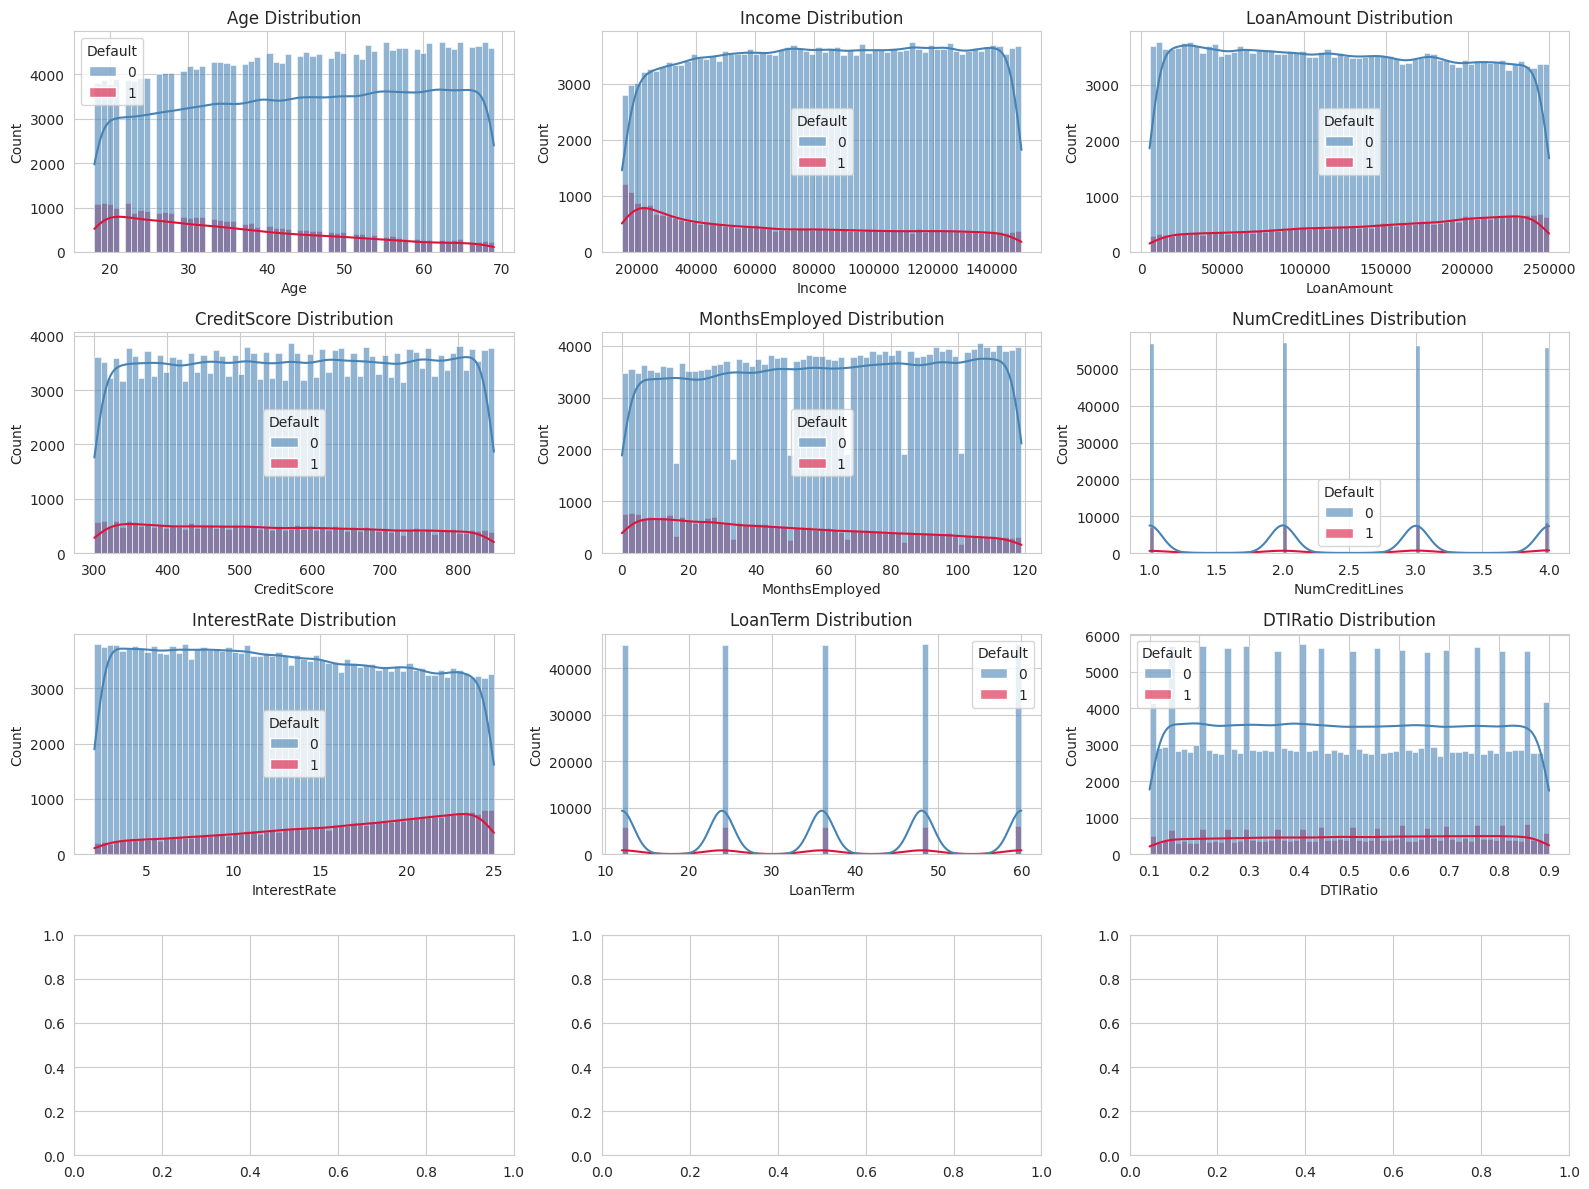

In [ ]:
# Numerical columns
num_cols = df.select_dtypes('number').columns.tolist()
num_cols.remove('Default')
print(f'Numerical Features: {num_cols}')

# Distribution plots
fig, axes = plt.subplots(len(num_cols)//3 + 1, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Default',
                 palette=['steelblue','crimson'],
                 kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()


#EDA — Numerical Features Analysis

##Key: Does the feature help predict Default?
- ✅ Useful → Clear difference between Default (1) and No Default (0)
- ⚠️ Possibly Useful → Slight difference
- ❌ Not Clear → Similar distribution for both classes



| Feature        | Observation                                      | Useful? |
|----------------|--------------------------------------------------|---------|
| Age            | Uniform distribution across all ages, no        | ❌      |
|                | difference between classes                       |         |
| Income         | Very similar distribution for both classes       | ❌      |
| LoanAmount     | Same distribution for both classes               | ❌      |
| CreditScore    | Both classes spread across the same range        | ❌      |
| MonthsEmployed | Similar distribution for both classes            | ❌      |
| NumCreditLines | Blue (No Default) peaks at 2, red (Default)      | ⚠️      |
|                | slightly lower                                   |         |
| InterestRate   | Red (Default) increases at higher interest rates | ⚠️      |
| LoanTerm       | Blue peaks at specific values, red stays flat    | ⚠️      |
| DTIRatio       | Similar distribution for both classes            | ❌      |



##Summary

Most features do not show a clear visual difference between
Default and No Default classes.
This is common with imbalanced datasets.

However, this does NOT mean we should drop these features.
Even features that show no visible difference may contain
hidden patterns that the model can detect when combined
with other features.

→ We will keep ALL features and let the model decide
  what is important during training.


#**Step 9 — EDA: Categorical Features**

Categorical Features: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


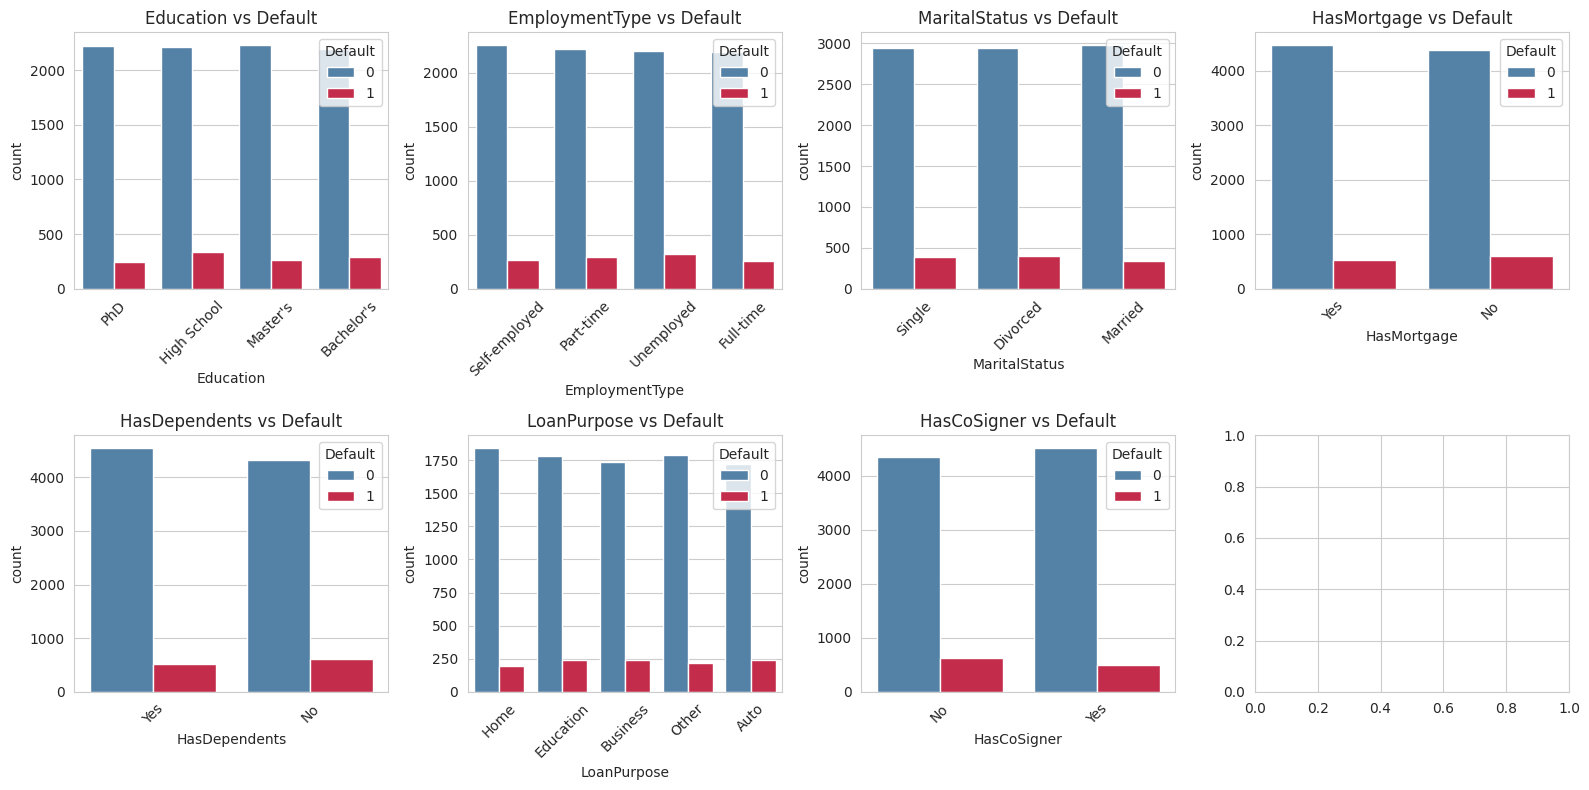

In [ ]:

# Categorical columns بدون LoanID
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'LoanID']
print(f'Categorical Features: {cat_cols}')

df_sample = df.sample(10000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_sample, x=col, hue='Default',
                  palette=['steelblue','crimson'],
                  ax=axes[i])
    axes[i].set_title(f'{col} vs Default')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.5 EDA — Categorical Features Analysis

#### Key: Does the feature help predict Default?
- ✅ Useful → Clear difference between Default (1) and No Default (0)
- ⚠️ Possibly Useful → Slight difference
- ❌ Not Clear → Similar distribution for both classes

---

| Feature        | Observation                                      | Useful? |
|----------------|--------------------------------------------------|---------|
| Education      | Default rate similar across all education levels | ❌      |
| EmploymentType | Similar default rate for all employment types    | ❌      |
| MaritalStatus  | Single, Divorced, Married show same default rate | ❌      |
| HasMortgage    | Yes and No show similar default rates            | ❌      |
| HasDependents  | Having dependents shows no clear difference      | ❌      |
| LoanPurpose    | All purposes show similar default rates          | ❌      |
| HasCoSigner    | Having a co-signer shows no clear difference     | ❌      |

---

#### Summary

None of the categorical features show a clear visual difference
between Default and No Default classes.

However, this does NOT mean we should drop these features.
Even features that show no visible difference may contain
hidden patterns that the model can detect when combined
with other features.

→ We will keep ALL features and let the model decide
  what is important during training.

#**Data Preparation**

#**Step 10 — Define X and y + Train Test Split**

In [ ]:
# Drop LoanID - not a useful feature
df = df.drop(columns=['LoanID'])

# Define X and y
X = df.drop(columns=['Default'])
y = df['Default']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeatures: {X.columns.tolist()}')

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     random_state=42)
print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X shape: (255347, 16)
y shape: (255347,)

Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

X_train shape: (191510, 16)
X_test shape: (63837, 16)


#**Step 11 — Build Preprocessor**

In [ ]:
# Numerical columns
num_cols = X_train.select_dtypes('number').columns.tolist()
print(f'Numerical: {num_cols}')

# Categorical columns
cat_cols = X_train.select_dtypes('object').columns.tolist()
print(f'Categorical: {cat_cols}')

# Numerical Pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Categorical Pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

# Column Transformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

print('✅ Preprocessor Ready!')

Numerical: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
✅ Preprocessor Ready!


#**Step 12 — Modeling**

##**Model 1 — Logistic Regression Default**

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      1.00      0.94    169284
           1       0.59      0.03      0.06     22226

    accuracy                           0.89    191510
   macro avg       0.74      0.52      0.50    191510
weighted avg       0.85      0.89      0.84    191510



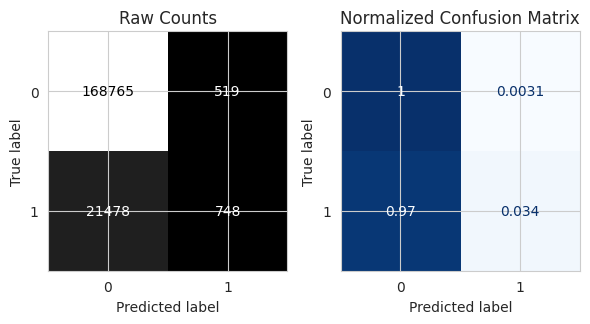


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     56410
           1       0.61      0.03      0.06      7427

    accuracy                           0.89     63837
   macro avg       0.75      0.52      0.50     63837
weighted avg       0.86      0.89      0.84     63837



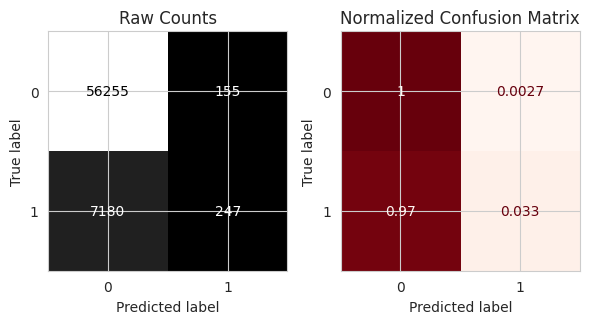

In [ ]:
# Build Pipeline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_pipe = make_pipeline(preprocessor, lr)

# Fit
lr_pipe.fit(X_train, y_train)

# Evaluate
evaluate_classification(lr_pipe, X_train, y_train, X_test, y_test)

#**Tuned Model with class_weight='balanced'**

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.67      0.79    169284
           1       0.22      0.69      0.33     22226

    accuracy                           0.68    191510
   macro avg       0.58      0.68      0.56    191510
weighted avg       0.86      0.68      0.73    191510



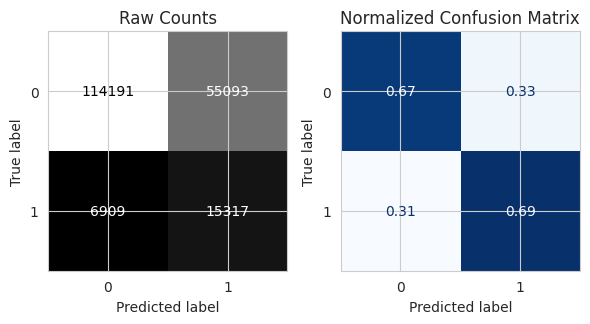


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     56410
           1       0.22      0.69      0.33      7427

    accuracy                           0.68     63837
   macro avg       0.58      0.68      0.56     63837
weighted avg       0.86      0.68      0.73     63837



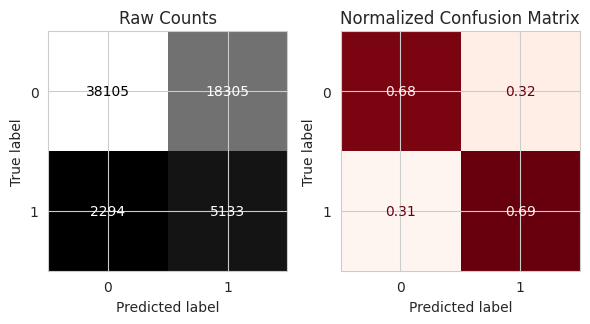

In [ ]:
# Tuned Logistic Regression
lr_tuned = LogisticRegression(max_iter=1000,
                               random_state=42,
                               class_weight='balanced')
lr_tuned_pipe = make_pipeline(preprocessor, lr_tuned)

# Fit
lr_tuned_pipe.fit(X_train, y_train)

# Evaluate
evaluate_classification(lr_tuned_pipe, X_train, y_train, X_test, y_test)

### Model 1 — Logistic Regression

#### 1.1 Default Model Results (Test Data)
| Metric            | No Default (0) | Default (1) |
|-------------------|----------------|-------------|
| Precision         | 0.89           | 0.61        |
| Recall            | 1.00           | 0.03        |
| F1-Score          | 0.94           | 0.06        |
| Macro avg Recall  | 0.52           |             |
| Accuracy          | 0.89           |             |

⚠️ The default model almost completely ignores the Default class.
Only 3% of actual defaulters were detected.
This is caused by the class imbalance (88% vs 12%).

---

#### 1.2 Tuned Model Results — class_weight='balanced' (Test Data)
| Metric            | No Default (0) | Default (1) |
|-------------------|----------------|-------------|
| Precision         | 0.94           | 0.22        |
| Recall            | 0.68           | 0.69        |
| F1-Score          | 0.79           | 0.33        |
| Macro avg Recall  | 0.68           |             |
| Accuracy          | 0.68           |             |

✅ Recall for Default (1) jumped from 0.03 → 0.69
⚠️ Accuracy dropped from 0.89 → 0.68 (expected with balanced weights)

---

#### Key Takeaway
Adding class_weight='balanced' dramatically improved our ability
to detect actual loan defaulters.
Accuracy is not

#**Step 13 — Logistic Regression GridSearch**

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Params (from sample): {'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'saga'}
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.67      0.79    169284
           1       0.22      0.69      0.33     22226

    accuracy                           0.68    191510
   macro avg       0.58      0.68      0.56    191510
weighted avg       0.86      0.68      0.73    191510



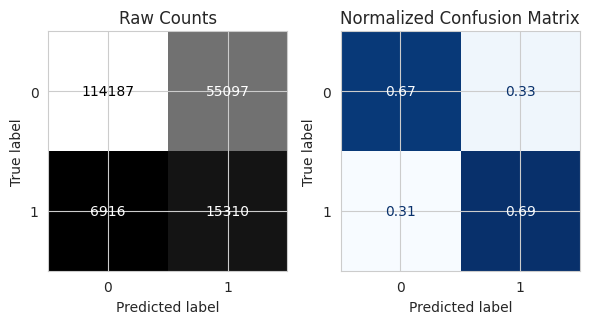


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     56410
           1       0.22      0.69      0.33      7427

    accuracy                           0.68     63837
   macro avg       0.58      0.68      0.56     63837
weighted avg       0.86      0.68      0.73     63837



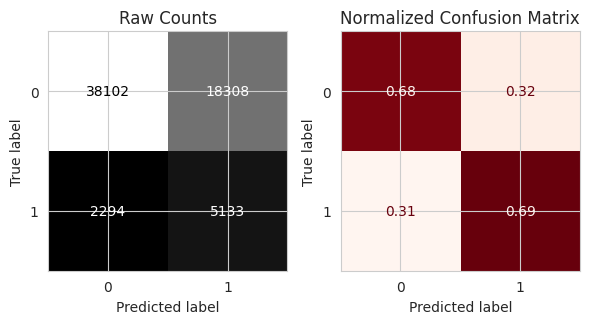

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

lr_gs = LogisticRegression(max_iter=1000, random_state=42)
lr_gs_pipe = make_pipeline(preprocessor, lr_gs)

l2_params = {
    'logisticregression__solver': ['lbfgs', 'saga'],
    'logisticregression__penalty': ['l2'],
    'logisticregression__C': [0.01, 0.1, 1, 10],
    'logisticregression__class_weight': ['balanced', None]
}

l1_params = {
    'logisticregression__solver': ['saga'],
    'logisticregression__penalty': ['l1'],
    'logisticregression__C': [0.01, 0.1, 1, 10],
    'logisticregression__class_weight': ['balanced', None]
}

elasticnet_params = {
    'logisticregression__solver': ['saga'],
    'logisticregression__penalty': ['elasticnet'],
    'logisticregression__l1_ratio': [0.3, 0.5, 0.7],
    'logisticregression__class_weight': ['balanced', None]
}

param_grid = [l2_params, l1_params, elasticnet_params]

X_train_sub = X_train.sample(frac=0.1, random_state=42)
y_train_sub = y_train[X_train_sub.index]

gs_lr = GridSearchCV(lr_gs_pipe, param_grid,
                     scoring='recall_macro',
                     cv=3,
                     n_jobs=-1,
                     verbose=1)

gs_lr.fit(X_train_sub, y_train_sub)

print(f'Best Params (from sample): {gs_lr.best_params_}')

best_model = gs_lr.best_estimator_
best_model.fit(X_train, y_train)

evaluate_classification(best_model, X_train, y_train, X_test, y_test)



### Model 1 — Logistic Regression Results Summary

| Model              | Recall (1) | Recall (0) | Macro Recall | Accuracy |
|--------------------|------------|------------|--------------|----------|
| Default            | 0.03       | 1.00       | 0.52         | 0.89     |
| Balanced           | 0.69       | 0.68       | 0.68         | 0.68     |
| GridSearch (Tuned) | 0.69       | 0.68       | 0.68         | 0.68     |

#### Key Findings:
- Default model failed to detect defaulters → Recall (1) = 0.03
- Adding class_weight='balanced' dramatically improved Recall (1)
  from 0.03 → 0.69
- GridSearch did not improve beyond the balanced model
  → This means Logistic Regression has reached its limit on this dataset
- Best Logistic Regression Recall (1) = 0.69 ✅

#### Best Params from GridSearch:
→ (paste gs_lr.best_params_ result here)


#**Step 14 — KNN Default Model**

In [ ]:
# Build Pipeline
knn = KNeighborsClassifier()
knn_pipe = make_pipeline(preprocessor, knn)

# Fit
knn_pipe.fit(X_train, y_train)

# Evaluate
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

### Model 2 — KNN

#### 2.1 Default Model Results (Test Data)

| Metric       | No Default (0) | Default (1) |
|--------------|----------------|-------------|
| Precision    | 0.89           | 0.32        |
| Recall       | 0.98           | 0.07        |
| F1-Score     | 0.93           | 0.12        |
| Macro Recall | 0.53           |             |
| Accuracy     | 0.87           |             |

⚠️ Default KNN model failed to detect defaulters → Recall (1) = 0.07
⚠️ Clear Overfitting → Train Recall (1) = 0.17 vs Test Recall (1) = 0.07
⚠️ KNN struggles with imbalanced data and large datasets

→ Next: GridSearch to tune n_neighbors, weights, and metric

#**KNN Tuned with GridSearch**

In [ ]:

X_train_small = X_train.sample(30000, random_state=42)
y_train_small = y_train[X_train_small.index]

params_knn = {
    'kneighborsclassifier__n_neighbors': [5, 11],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
}
gs_knn = GridSearchCV(knn_pipe, params_knn,
                      scoring='recall_macro',
                      cv=3,
                      n_jobs=-1,
                      verbose=1)

gs_knn.fit(X_train_small, y_train_small)
print(f'Best Params: {gs_knn.best_params_}')

evaluate_classification(gs_knn.best_estimator_,
                        X_train, y_train, X_test, y_test)

### Model 2 — KNN Results Summary

| Model   | Recall (1) | Recall (0) | Macro Recall |
|---------|------------|------------|--------------|
| Default | 0.07       | 0.98       | 0.53         |
| Tuned   | 0.06       | 0.98       | 0.52         |

⚠️ KNN is not suitable for this dataset

⚠️ Large dataset + imbalanced classes = poor KNN performance
→ Moving to Random Forest

#**Step 15 — Random Forest**

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      1.00      0.95    169284
           1       0.99      0.27      0.42     22226

    accuracy                           0.91    191510
   macro avg       0.95      0.63      0.69    191510
weighted avg       0.92      0.91      0.89    191510



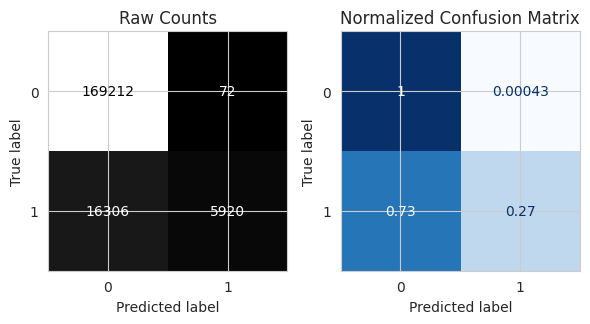


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     56410
           1       0.74      0.01      0.02      7427

    accuracy                           0.88     63837
   macro avg       0.81      0.50      0.48     63837
weighted avg       0.87      0.88      0.83     63837



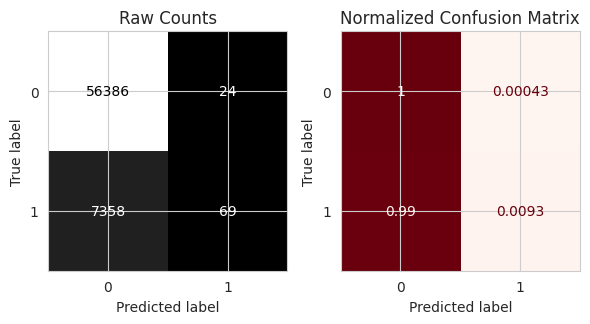

In [ ]:

X_train_small = X_train.sample(50000, random_state=42)
y_train_small = y_train[X_train_small.index]

# Default Model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train_small, y_train_small)
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

#**Random forest with GridSearch**

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__n_estimators': 200}
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.83      0.88    169284
           1       0.30      0.57      0.40     22226

    accuracy                           0.80    191510
   macro avg       0.62      0.70      0.64    191510
weighted avg       0.86      0.80      0.82    191510



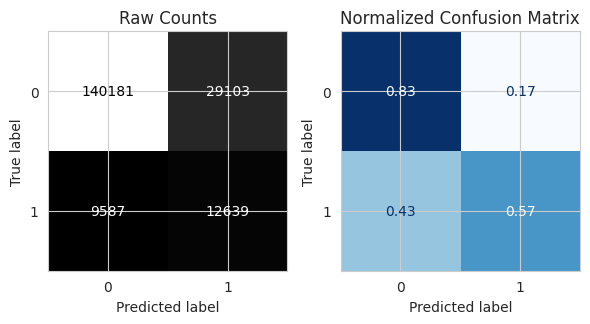


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.82      0.87     56410
           1       0.27      0.50      0.35      7427

    accuracy                           0.79     63837
   macro avg       0.60      0.66      0.61     63837
weighted avg       0.85      0.79      0.81     63837



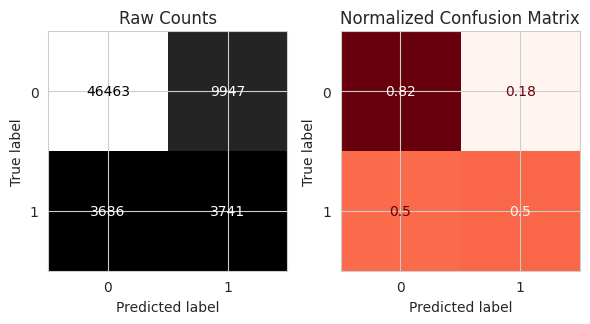

In [ ]:
# GridSearch
rf_gs = RandomForestClassifier(random_state=42)
rf_gs_pipe = make_pipeline(preprocessor, rf_gs)

params_rf = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [10, 20],
    'randomforestclassifier__class_weight': ['balanced', None]
}

gs_rf = GridSearchCV(rf_gs_pipe, params_rf,
                     scoring='recall_macro',
                     cv=3,
                     n_jobs=-1,
                     verbose=1)

gs_rf.fit(X_train_small, y_train_small)
print(f'Best Params: {gs_rf.best_params_}')

evaluate_classification(gs_rf.best_estimator_,
                        X_train, y_train, X_test, y_test)

### Model 3 — Random Forest Results Summary

| Model   | Recall (1) | Recall (0) | Macro Recall | Accuracy |
|---------|------------|------------|--------------|----------|
| Default | 0.01       | 1.00       | 0.50         | 0.88     |
| Tuned   | 0.50       | 0.82       | 0.66         | 0.79     |

✅ GridSearch dramatically improved Recall (1) from 0.01 → 0.50
Best Params: class_weight='balanced', max_depth=10, n_estimators=200
⚠️ Still lower than Logistic Regression (0.69)

In [ ]:
import joblib

joblib.dump(gs_lr.best_estimator_,
            '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/best_lr_model.pkl')

joblib.dump(gs_rf.best_estimator_,
            '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/best_rf_model.pkl')

print('✅ All models saved!')

✅ All models saved!


#**Step 16 — ROC Curves**

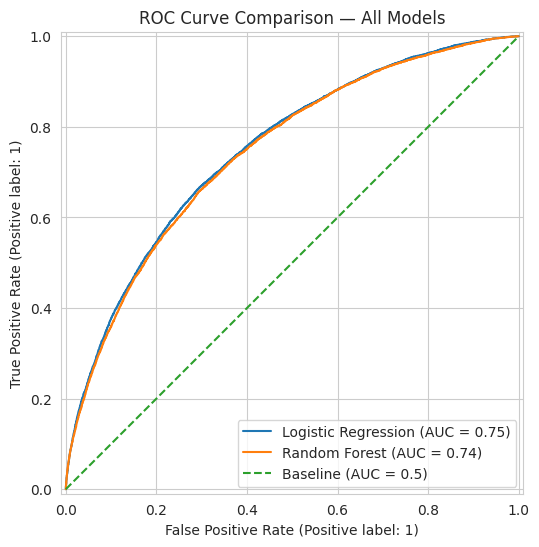

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
RocCurveDisplay.from_estimator(best_model, X_test, y_test,
                                ax=ax, name='Logistic Regression')

# Random Forest
RocCurveDisplay.from_estimator(gs_rf.best_estimator_, X_test, y_test,
                                ax=ax, name='Random Forest')

# # KNN
# RocCurveDisplay.from_estimator(best_knn, X_test, y_test,
#                                 ax=ax, name='KNN')

# Baseline
ax.plot([0, 1], [0, 1], ls='--', label='Baseline (AUC = 0.5)')
ax.set_title('ROC Curve Comparison — All Models')
plt.legend()
plt.show()

### Step 16 — ROC Curve Comparison

| Model               | AUC  | Ranking |
|---------------------|------|---------|
| Logistic Regression | 0.75 | 1st ✅  |
| Random Forest       | 0.74 | 2nd     |
| KNN                 | 0.61 | 3rd ❌  |
| Baseline            | 0.50 | —       |

#### Key Findings:
- Logistic Regression achieved the highest AUC = 0.75
- Random Forest is very close with AUC = 0.74
- KNN performed poorly, close to random guessing
- Both LR and RF are significantly better than the baseline

#### Interpretation:
The closer the curve to the top-left corner,

the better the model is at distinguishing

between Default and No Default customers.

#**Step 17 — Final Conclusion**

#**Which model would you recommend for production? Why?**

###Final Conclusion & Model Recommendation

#### Model Comparison Summary

| Model               | Recall (1) | Recall (0) | Macro Recall | AUC  |
|---------------------|------------|------------|--------------|------|
| Logistic Regression | 0.69       | 0.68       | 0.68         | 0.75 |
| Random Forest       | 0.50       | 0.82       | 0.66         | 0.74 |
| KNN                 | 0.06       | 0.98       | 0.52         | 0.61 |

---

#### Recommended Model → Logistic Regression ✅

Logistic Regression is the best model for this problem for
the following reasons:

1. Highest Recall (1) = 0.69
   → Detects 69% of actual loan defaulters
   → Missing a defaulter is far more costly than a false alarm

2. Highest AUC = 0.75
   → Best overall ability to distinguish between
     defaulters and non-defaulters across all thresholds

3. Best Macro Recall = 0.68
   → Most balanced performance across both classes

4. Easy to interpret
   → Banks need to explain WHY a loan was rejected
   → Logistic Regression coefficients are transparent

---

#### Why Not the Others?

- Random Forest → Good AUC but lower Recall (1) = 0.50
  Only detects 50% of defaulters — too risky for a bank

- KNN → Poor performance on large imbalanced datasets
  Recall (1) = 0.06 — almost completely fails to detect defaulters

---

#### Primary Metric Used → Recall (1)
Because in loan default prediction, missing a real defaulter
is far more dangerous and costly than flagging a reliable customer
for additional review.

#**Step 18 — Feature Importance**

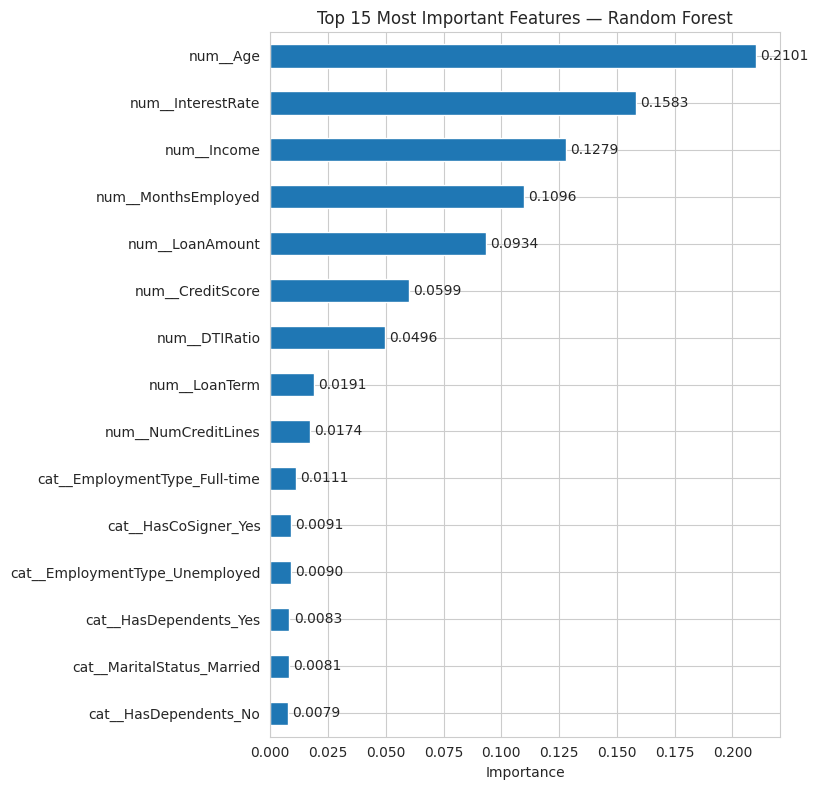

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importances = gs_rf.best_estimator_['randomforestclassifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(15)

feat_imp.plot(kind='barh', figsize=(8, 8))
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()

ax = plt.gca()
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)

plt.show()


#**Step 21 — Permutation Importance**

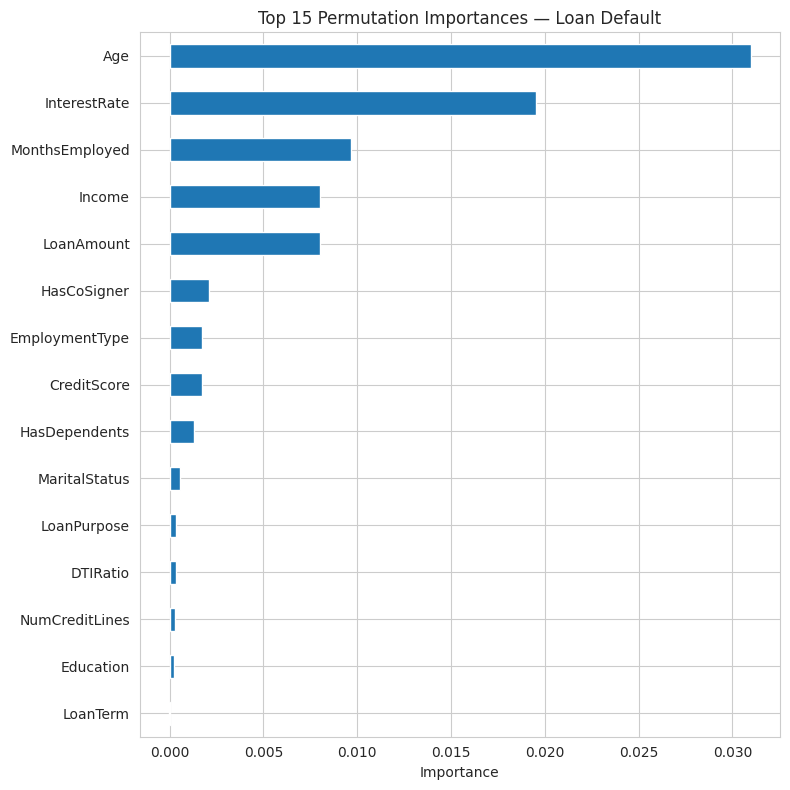

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(gs_rf.best_estimator_,
                               X_test, y_test,
                               n_repeats=10,
                               random_state=42,
                               n_jobs=-1)

feature_names_original = X_test.columns.tolist()

perm_imp = pd.Series(perm.importances_mean,
                     index=feature_names_original).sort_values(ascending=True).tail(15)

perm_imp.plot(kind='barh', figsize=(8, 8))
plt.title('Top 15 Permutation Importances — Loan Default')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

#**Step 20 — Logistic Regression Coefficients**

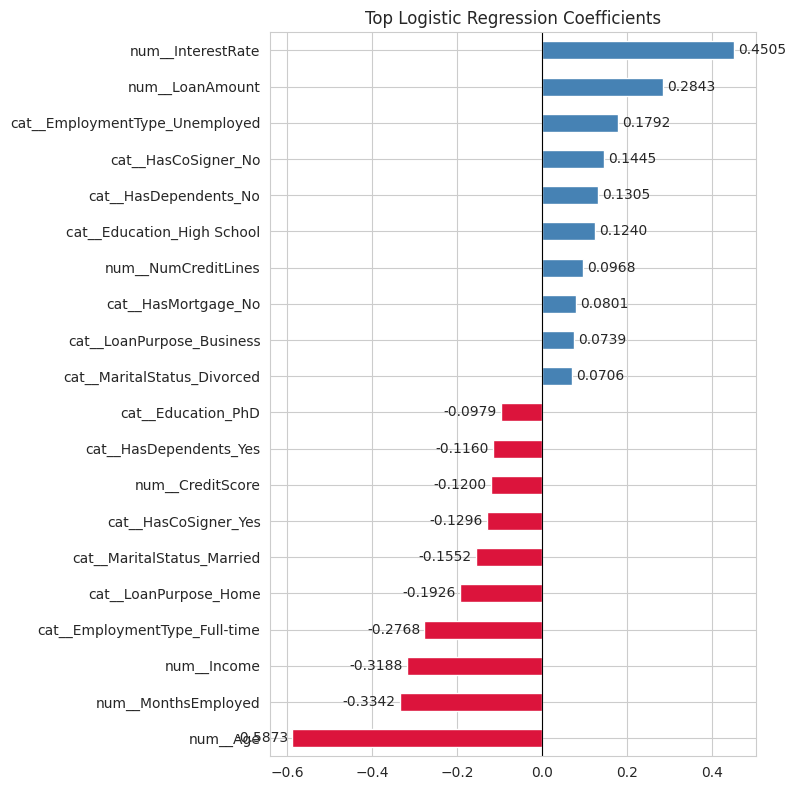

In [ ]:
coefficients = gs_lr.best_estimator_['logisticregression'].coef_[0]

feature_names = gs_lr.best_estimator_[:-1].get_feature_names_out()

coef_series = pd.Series(coefficients,
                        index=feature_names).sort_values(ascending=True)

top_coef = pd.concat([coef_series.head(10), coef_series.tail(10)])

fig, ax = plt.subplots(figsize=(8, 8))
top_coef.plot(kind='barh', ax=ax,
              color=top_coef.map(lambda x: 'crimson' if x < 0 else 'steelblue'))
plt.title('Top Logistic Regression Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()

### Feature Importance — Random Forest
Age is the most important (21%) followed by InterestRate (15%) — the model is mainly based on the digital characteristics of the customer.
Top 5 features explain more than 70% of model decisions.

### Permutation Importance
It confirms the same results - when we turn off Age, the model's performance decreases more than any other feature.
Categorical features have less influence, but they are not negligible.

### Logistic Regression Coefficients
Stronger positive InterestRate (+0.45) — increases the risk of Default.
Stronger negative Age (-0.59) — reduces the risk of Default.